In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path
from scipy.stats import norm

from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

df = pd.read_csv("../data/fact_sales_store_sku_daily.csv")
df["date"] = pd.to_datetime(df["date"])

In [2]:
#Paths
BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "raw_data"
DATA_DIR = BASE_DIR / "data"

SALES_PATH = RAW_DIR / "sales_daily.csv"
PRODUCTS_PATH = RAW_DIR / "products.json"

HORIZON = 28
TARGET_COL = "true_demand_units"  

sales = pd.read_csv("../raw_data/sales_daily.csv")
forecast = pd.read_csv(DATA_DIR / "forecast_store_sku_daily_next_28days.csv")
inventory = pd.read_csv(DATA_DIR / "fact_inventory_store_sku_daily.csv")
po = pd.read_csv(RAW_DIR / "purchase_orders.csv")
products = pd.read_json(RAW_DIR / "products.json")
stores = pd.read_csv(RAW_DIR / "stores.csv")
replenishment = pd.read_csv("../data/replenishment_inputs_store_sku.csv")

with open(RAW_DIR / "products.json", "r", encoding="utf-8") as f:
    products = pd.DataFrame(json.load(f))

# normalize columns
for updated_data in [sales, inventory, po, stores, products]:
    updated_data.columns = updated_data.columns.str.strip().str.lower()

replenishment.columns = replenishment.columns.str.lower()

sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
forecast["date"] = pd.to_datetime(forecast["date"])
inventory["date"] = pd.to_datetime(inventory["date"], errors="coerce")

# normalize IDs
sales["store_id"] = sales["store_id"].astype(str).str.strip().str.upper()
sales["sku_id"] = sales["sku_id"].astype(str).str.strip().str.upper()
inventory["store_id"] = inventory["store_id"].astype(str).str.strip().str.upper()
inventory["sku_id"] = inventory["sku_id"].astype(str).str.strip().str.upper()
po["store_id"] = po["store_id"].astype(str).str.strip().str.upper()
po["sku_id"] = po["sku_id"].astype(str).str.strip().str.upper()
products["sku_id"] = products["sku_id"].astype(str).str.strip().str.upper()
products["category"] = products["category"].astype(str).str.strip().str.upper()

sales = sales.merge(products[["sku_id","category"]], on="sku_id", how="left")
inventory = inventory.merge(products[["sku_id","category"]], on="sku_id", how="left")

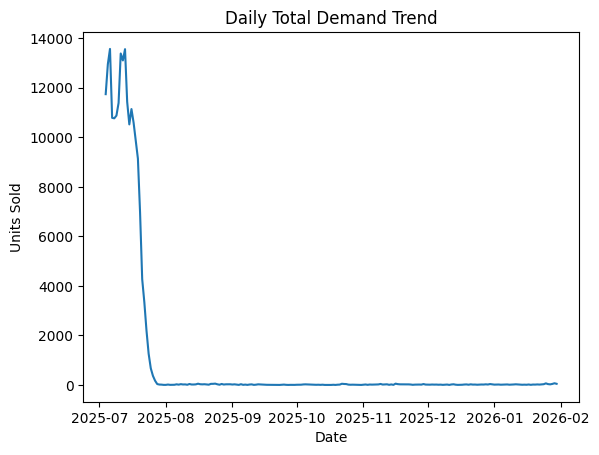

In [3]:
#PART C - 1.DEMAND UNDERSTANDING
#Overall Demand Trend 
daily_trend = df.groupby("date")["units_sold"].sum().reset_index()

plt.figure()
plt.plot(daily_trend["date"], daily_trend["units_sold"])
plt.title("Daily Total Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

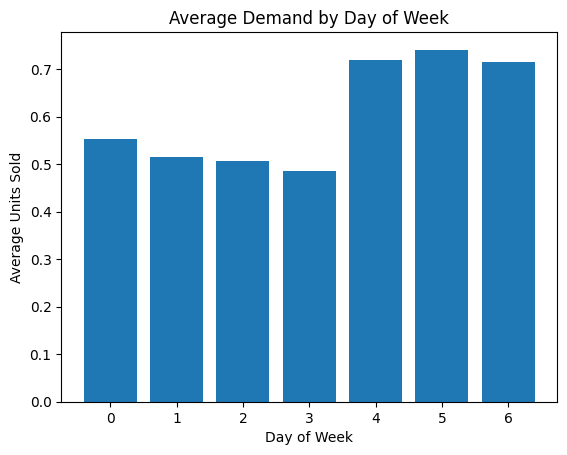

In [4]:
#Weekly Seasonality Pattern
weekly_pattern = df.groupby("day_of_week")["units_sold"].mean().reset_index()

plt.figure()
plt.bar(weekly_pattern["day_of_week"], weekly_pattern["units_sold"])
plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.show()

In [5]:
#Promo and Holiday Effect on demand
# a. Promo Impact
promo_analysis = df.groupby("promo_flag")["units_sold"].mean().reset_index()
print(promo_analysis)

   promo_flag  units_sold
0           0    0.678136
1           1    0.012346


In [6]:
# b. Holiday Impact
holiday_analysis = df.groupby("holiday_flag")["units_sold"].mean().reset_index()
print(holiday_analysis)

   holiday_flag  units_sold
0             0    0.577226
1             1    2.071914


In [7]:
#Top SKUs by Volume and Revenue
# a. Top SKUs By Volume
top_volume = (
    df.groupby("sku_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top_volume)


    sku_id  units_sold
0  SKU0077        3964
1  SKU0085        3948
2  SKU0044        3899
3  SKU0036        3898
4  SKU0074        3897
5  SKU0019        3896
6  SKU0038        3892
7  SKU0082        3887
8  SKU0060        3886
9  SKU0062        3873


In [8]:
# b. Top SKUs By Revenue
top_revenue = (
    df.groupby("sku_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top_revenue)

    sku_id     revenue
0  SKU0051  1768502.50
1  SKU0019  1627164.40
2  SKU0058  1580304.30
3  SKU0053  1489297.73
4  SKU0023  1420288.00
5  SKU0061  1400202.18
6  SKU0075  1375112.70
7  SKU0004  1339218.99
8  SKU0006  1176543.62
9  SKU0048  1137109.35


In [9]:
#Part C: 2.FORECASTING (Mandatory)
#Helper Metrics
def MAPE(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denominator = np.where(y_true == 0, np.nan, np.abs(y_true))
    return np.nanmean(np.abs(y_true - y_pred) / denominator)

def WAPE(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denominator = np.nansum(np.abs(y_true))
    return np.nan if denominator == 0 else np.nansum(np.abs(y_true - y_pred)) / denominator

In [10]:
#Load Data
sales = pd.read_csv(SALES_PATH)
sales.columns = sales.columns.str.strip().str.lower()
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")

# normalize IDs
sales["store_id"] = sales["store_id"].astype(str).str.strip().str.upper()
sales["sku_id"] = sales["sku_id"].astype(str).str.strip().str.upper()

# load products for category
with open(PRODUCTS_PATH, "r", encoding="utf-8") as f:
    products = pd.DataFrame(json.load(f))
products.columns = products.columns.str.strip().str.lower()
products["sku_id"] = products["sku_id"].astype(str).str.strip().str.upper()
products["category"] = products["category"].astype(str).str.strip().str.upper()

sales = sales.merge(products[["sku_id", "category"]], on="sku_id", how="left")

# target
sales["y"] = sales[TARGET_COL].astype(float)

# required columns
required = ["promo_flag", "holiday_flag", "day_of_week"]
for c in required:
    if c not in sales.columns:
        raise ValueError(f"Missing column in sales_daily.csv: {c}")

sales = sales.sort_values(["store_id", "sku_id", "date"]).reset_index(drop=True)

print("Rows:", len(sales))
print("Date range:", sales["date"].min().date(), "to", sales["date"].max().date())
print("Unique store-SKU pairs:", sales[["store_id","sku_id"]].drop_duplicates().shape[0])

Rows: 342674
Date range: 2025-07-04 to 2026-01-30
Unique store-SKU pairs: 1620


In [11]:
#Train Test Split for last 20 days data
max_date = sales["date"].max()
test_start = max_date - pd.Timedelta(days=HORIZON - 1)

train = sales[sales["date"] < test_start].copy()
test  = sales[sales["date"] >= test_start].copy()

print("Train:", train["date"].min().date(), "to", train["date"].max().date(), "| rows:", len(train))
print("Test :", test["date"].min().date(),  "to", test["date"].max().date(),  "| rows:", len(test))

Train: 2025-07-04 to 2026-01-02 | rows: 297200
Test : 2026-01-03 to 2026-01-30 | rows: 45474


In [12]:
#######Approach A - Baseline(Seasonal Naive by days of week)
dow_mean = (train.groupby(["store_id", "sku_id", "day_of_week"])["y"]
            .mean().reset_index(name="dow_mean"))

sku_mean = (train.groupby(["store_id", "sku_id"])["y"]
            .mean().reset_index(name="sku_mean"))

test_base = test.merge(dow_mean, on=["store_id","sku_id","day_of_week"], how="left")
test_base = test_base.merge(sku_mean, on=["store_id","sku_id"], how="left")

test_base["pred_baseline"] = test_base["dow_mean"].fillna(test_base["sku_mean"]).fillna(0)

# overall
baseline_overall = {
    "approach": "baseline_seasonal_naive",
    "MAPE": MAPE(test_base["y"], test_base["pred_baseline"]),
    "WAPE": WAPE(test_base["y"], test_base["pred_baseline"])
}
baseline_overall

{'approach': 'baseline_seasonal_naive',
 'MAPE': np.float64(0.8076068765937637),
 'WAPE': np.float64(0.5066611935078437)}

In [13]:
#Approach B — Simple Regression (Promo + Holiday + Day-of-Week)
features_num = ["promo_flag", "holiday_flag"]
features_cat = ["day_of_week"]

X_train = train[features_num + features_cat]
y_train = train["y"]
X_test  = test[features_num + features_cat]
y_test  = test["y"]

# preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), features_num),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), features_cat)
    ]
)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("lr", LinearRegression())
])

model.fit(X_train, y_train)
test_reg = test.copy()
test_reg["pred_model"] = np.clip(model.predict(X_test), 0, None)

model_overall = {
    "approach": "model_regression_simple",
    "MAPE": MAPE(test_reg["y"], test_reg["pred_model"]),
    "WAPE": WAPE(test_reg["y"], test_reg["pred_model"])
}
model_overall

{'approach': 'model_regression_simple',
 'MAPE': np.float64(1.148806965533656),
 'WAPE': np.float64(0.6218403000642899)}

In [14]:
#Overall Comparison
overall_results = pd.DataFrame([baseline_overall, model_overall])
overall_results

,approach,MAPE,WAPE
0,baseline_seasonal_naive,0.807607,0.506661
1,model_regression_simple,1.148807,0.621840


In [15]:
#By Category(MAPE/WAPE)
baseline_by_cat = (test_base.groupby("category")
                   .apply(lambda g: pd.Series({
                       "MAPE": MAPE(g["y"], g["pred_baseline"]),
                       "WAPE": WAPE(g["y"], g["pred_baseline"]),
                       "rows": len(g)
                   }))
                   .reset_index())
baseline_by_cat["approach"] = "baseline_seasonal_naive"

model_by_cat = (test_reg.groupby("category")
                .apply(lambda g: pd.Series({
                    "MAPE": MAPE(g["y"], g["pred_model"]),
                    "WAPE": WAPE(g["y"], g["pred_model"]),
                    "rows": len(g)
                }))
                .reset_index())
model_by_cat["approach"] = "model_regression_simple"

by_category_results = pd.concat([baseline_by_cat, model_by_cat], ignore_index=True)
by_category_results = by_category_results[["approach","category","MAPE","WAPE","rows"]].sort_values(["category","approach"])
by_category_results

C:\Users\ayush\AppData\Local\Temp\ipykernel_876\1422622058.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\ayush\AppData\Local\Temp\ipykernel_876\1422622058.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,approach,category,MAPE,WAPE,rows
0,baseline_seasonal_naive,BEVERAGES,0.874601,0.514617,10106.0
6,model_regression_simple,BEVERAGES,0.961392,0.534685,10106.0
1,baseline_seasonal_naive,DAIRY,0.792492,0.480904,6058.0
7,model_regression_simple,DAIRY,0.659112,0.504369,6058.0
2,baseline_seasonal_naive,GROCERY,0.789367,0.477890,8086.0
8,model_regression_simple,GROCERY,0.568996,0.551265,8086.0
3,baseline_seasonal_naive,HOMECARE,0.724719,0.607665,7081.0
9,model_regression_simple,HOMECARE,2.240006,1.336631,7081.0
4,baseline_seasonal_naive,PERSONALCARE,0.777023,0.588246,6567.0
10,model_regression_simple,PERSONALCARE,1.975828,1.086566,6567.0


In [16]:
#wHICH APPROACH PERFORMS BETTER AND WHY
output_result = overall_results.sort_values("WAPE").iloc[0]
output_result

approach    baseline_seasonal_naive
MAPE                       0.807607
WAPE                       0.506661
Name: 0, dtype: object

In [17]:
if output_result["approach"] == "model_regression_simple":
    print("✅ Simple Regression performs better (lower WAPE).")
    print("Why: It learns systematic uplift from promo/holiday while still capturing weekday seasonality.")
else:
    print("✅ Baseline performs better (lower WAPE).")
    print("Why: Demand is dominated by weekly repetition; promo/holiday signals add limited incremental value.")

✅ Baseline performs better (lower WAPE).
Why: Demand is dominated by weekly repetition; promo/holiday signals add limited incremental value.


In [18]:
##Generate Next 28 Days Using Baseline
if baseline_overall["WAPE"] < model_overall["WAPE"]:
    final_model = "baseline"
else:
    final_model = "regression"

# Compute weekday averages from ALL history
dow_mean_full = (
    sales.groupby(["store_id", "sku_id", "day_of_week"])["y"]
    .mean()
    .reset_index(name="dow_mean")
)

# Future dates
future_dates = pd.date_range(max_date + pd.Timedelta(days=1), periods=28, freq="D")
future = pd.DataFrame({"date": future_dates})
future["day_of_week"] = future["date"].dt.dayofweek

# Replicate for all store-sku pairs
pairs = sales[["store_id", "sku_id", "category"]].drop_duplicates()
future = pairs.merge(future, how="cross")

# Merge weekday average
future = future.merge(
    dow_mean_full,
    on=["store_id", "sku_id", "day_of_week"],
    how="left"
)

future["forecast_demand"] = future["dow_mean"].fillna(0)

# Save
future_out = future[[
    "date", "store_id", "sku_id", "category", "forecast_demand"
]]

future_out.to_csv(DATA_DIR / "forecast_store_sku_daily_next_28days.csv", index=False)

print("Saved baseline forecast for next 28 days")

Saved baseline forecast for next 28 days


In [19]:
#Part C - 3.INVENTORY RISK SEGMENTATION
#Prepare required inputs
latest_inventory = (
    inventory.sort_values("date")
    .groupby(["store_id", "sku_id"])
    .tail(1)
)[["store_id", "sku_id", "on_hand_units"]]

# Average daily forecast for the next 28 days
avg_forecast = (
    forecast.groupby(["store_id", "sku_id"])["forecast_demand"]
    .mean()
    .reset_index(name="avg_daily_forecast")
)

# Lead time
lead_time = (
    po.groupby(["store_id", "sku_id"])["lead_time_days"]
    .mean()
    .reset_index()
)

# Merge all
risk_df = (
    latest_inventory
    .merge(avg_forecast, on=["store_id", "sku_id"], how="left")
    .merge(lead_time, on=["store_id", "sku_id"], how="left")
    .merge(products[["sku_id", "category"]], on="sku_id", how="left")
)

risk_df["avg_daily_forecast"] = risk_df["avg_daily_forecast"].fillna(0)
risk_df["lead_time_days"] = risk_df["lead_time_days"].fillna(risk_df["lead_time_days"].median())

In [20]:
#STOCKOUT RISK CALCULATION
risk_df["projected_inventory"] = (
    risk_df["on_hand_units"] -
    risk_df["avg_daily_forecast"] * risk_df["lead_time_days"]
)

risk_df["stockout_risk_flag"] = risk_df["projected_inventory"] <= 0

In [21]:
#OVERSTOCK RISK CALCULATION
# Days of inventory
risk_df["DOH"] = risk_df["on_hand_units"] / risk_df["avg_daily_forecast"]
risk_df["DOH"] = risk_df["DOH"].replace([np.inf, -np.inf], np.nan)

# Category thresholds
DOH_THRESHOLD = {
    "DAIRY": 7,
    "GROCERY": 30,
    "BEVERAGES": 40,
    "SNACKS": 35,
    "HOMECARE": 45,
    "PERSONALCARE": 50
}

risk_df["category"] = risk_df["category"].str.upper()
risk_df["doh_threshold"] = risk_df["category"].map(DOH_THRESHOLD)

risk_df["overstock_risk_flag"] = risk_df["DOH"] > risk_df["doh_threshold"]

# Days of inventory
risk_df["DOH"] = risk_df["on_hand_units"] / risk_df["avg_daily_forecast"]
risk_df["DOH"] = risk_df["DOH"].replace([np.inf, -np.inf], np.nan)

# Category thresholds
DOH_THRESHOLD = {
    "DAIRY": 7,
    "GROCERY": 30,
    "BEVERAGES": 40,
    "SNACKS": 35,
    "HOMECARE": 45,
    "PERSONALCARE": 50
}

risk_df["category"] = risk_df["category"].str.upper()
risk_df["doh_threshold"] = risk_df["category"].map(DOH_THRESHOLD)

risk_df["overstock_risk_flag"] = risk_df["DOH"] > risk_df["doh_threshold"]

In [22]:
#LABEL SEGMENTATION
def classify(row):
    if row["stockout_risk_flag"]:
        return "Stockout Risk"
    elif row["overstock_risk_flag"]:
        return "Overstock Risk"
    else:
        return "Healthy"

risk_df["risk_segment"] = risk_df.apply(classify, axis=1)

risk_df["risk_segment"].value_counts()

risk_segment
Stockout Risk    1619
Healthy             1
Name: count, dtype: int64

In [23]:
#Top 10 Stockout Risk Store-SKUs
top_stockout = (
    risk_df[risk_df["risk_segment"] == "Stockout Risk"]
    .sort_values("projected_inventory")
    .head(10)
)

top_stockout

,store_id,sku_id,on_hand_units,avg_daily_forecast,lead_time_days,category,projected_inventory,stockout_risk_flag,DOH,doh_threshold,overstock_risk_flag,risk_segment
886,ST003,SKU0069,0.0,21.818587,4.0,GROCERY,-87.274347,True,0.0,30,False,Stockout Risk
828,ST003,SKU0077,0.0,21.461598,4.0,GROCERY,-85.846390,True,0.0,30,False,Stockout Risk
831,ST003,SKU0074,0.0,21.021198,4.0,GROCERY,-84.084793,True,0.0,30,False,Stockout Risk
868,ST003,SKU0036,0.0,20.834101,4.0,GROCERY,-83.336406,True,0.0,30,False,Stockout Risk
882,ST003,SKU0044,0.0,20.754531,4.0,GROCERY,-83.018126,True,0.0,30,False,Stockout Risk
823,ST003,SKU0082,0.0,20.752688,4.0,GROCERY,-83.010753,True,0.0,30,False,Stockout Risk
904,ST003,SKU0051,0.0,20.217051,4.0,GROCERY,-80.868203,True,0.0,30,False,Stockout Risk
907,ST003,SKU0048,0.0,20.129032,4.0,GROCERY,-80.516129,True,0.0,30,False,Stockout Risk
895,ST003,SKU0060,0.0,20.057296,4.0,GROCERY,-80.229186,True,0.0,30,False,Stockout Risk
866,ST003,SKU0038,0.0,20.010417,4.0,GROCERY,-80.041667,True,0.0,30,False,Stockout Risk


In [24]:
#Top 10 Overstock Risk Store-SKUs
top_overstock = (
    risk_df[risk_df["risk_segment"] == "Overstock Risk"]
    .sort_values("DOH", ascending=False)
    .head(10)
)

top_overstock

,store_id,sku_id,on_hand_units,avg_daily_forecast,lead_time_days,category,projected_inventory,stockout_risk_flag,DOH,doh_threshold,overstock_risk_flag,risk_segment


In [25]:
#RECOMMENDED ACTIONS
def action(row):
    if row["risk_segment"] == "Stockout Risk":
        return "Urgent Replenishment / Inter-store Transfer"
    elif row["risk_segment"] == "Overstock Risk":
        return "Discount / Promotion / Reduce Reorder Qty"
    else:
        return "Maintain Current Policy"

risk_df["recommended_action"] = risk_df.apply(action, axis=1)

risk_df[["store_id","sku_id","risk_segment","recommended_action"]].head()

,store_id,sku_id,risk_segment,recommended_action
0,ST012,SKU0088,Stockout Risk,Urgent Replenishment / Inter-store Transfer
1,ST013,SKU0005,Stockout Risk,Urgent Replenishment / Inter-store Transfer
2,ST013,SKU0004,Stockout Risk,Urgent Replenishment / Inter-store Transfer
3,ST013,SKU0003,Stockout Risk,Urgent Replenishment / Inter-store Transfer
4,ST013,SKU0002,Stockout Risk,Urgent Replenishment / Inter-store Transfer


In [26]:
#PART C: 4.REPLENISHMENT INVESTIGATION TABLE
#STEP 1 — Find Top 2 Categories with Highest Stockouts
stockout_rate = (
    inventory.groupby("category")["stockout_flag"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

top2_categories = stockout_rate.head(2)
top2_categories

,category,stockout_flag
0,BEVERAGES,0.921538
1,HOMECARE,0.920879


In [27]:
#STEP 2 — Calculate Lost Sales Proxy
#Lost sales = True demand – Units sold
sales["lost_sales_units"] = (
    sales["true_demand_units"] - sales["units_sold"]
).clip(lower=0)

cat_lost_sales = (
    sales[sales["category"].isin(top2_categories["category"])]
    .groupby("category")
    .agg(
        total_lost_sales=("lost_sales_units","sum"),
        avg_demand=("true_demand_units","mean"),
        demand_std_dev=("true_demand_units","std")
    )
    .reset_index()
)

cat_lost_sales

,category,total_lost_sales,avg_demand,demand_std_dev
0,BEVERAGES,518233,7.372500,5.274765
1,HOMECARE,162708,3.306871,2.721968


In [28]:
#STEP 3 — Stores with Highest Demand Volatility
store_volatility = (
    sales[sales["category"].isin(top2_categories["category"])]
    .groupby(["category","store_id"])["true_demand_units"]
    .std()
    .reset_index(name="demand_std_dev")
)

top_volatile_stores = (
    store_volatility.sort_values(["category","demand_std_dev"], ascending=[True,False])
    .groupby("category")
    .head(3)
)

top_volatile_stores

,category,store_id,demand_std_dev
2,BEVERAGES,ST003,7.082559
7,BEVERAGES,ST008,6.574561
10,BEVERAGES,ST011,6.570054
20,HOMECARE,ST003,3.537327
28,HOMECARE,ST011,3.391336
25,HOMECARE,ST008,3.377258


In [29]:
#STEP 4 — Create Final Investigation Table
# Merge stockout rate + lost sales
investigation_table = cat_lost_sales.merge(
    stockout_rate,
    on="category",
    how="left"
)

# Add hypotheses & experiments
investigation_table["hypothesis_1"] = "Lead time too long vs demand variability"
investigation_table["experiment_1"] = "Check correlation between lead_time_days and stockout rate"

investigation_table["hypothesis_2"] = "Promotions increase demand but replenishment not adjusted"
investigation_table["experiment_2"] = "Compare demand on promo days vs non-promo days"

investigation_table["hypothesis_3"] = "Safety stock too low for volatile stores"
investigation_table["experiment_3"] = "Simulate higher service level and measure stockout reduction"

investigation_table

,category,total_lost_sales,avg_demand,demand_std_dev,stockout_flag,hypothesis_1,experiment_1,hypothesis_2,experiment_2,hypothesis_3,experiment_3
0,BEVERAGES,518233,7.372500,5.274765,0.921538,Lead time too long vs demand variability,Check correlation between lead_time_days and s...,Promotions increase demand but replenishment n...,Compare demand on promo days vs non-promo days,Safety stock too low for volatile stores,Simulate higher service level and measure stoc...
1,HOMECARE,162708,3.306871,2.721968,0.920879,Lead time too long vs demand variability,Check correlation between lead_time_days and s...,Promotions increase demand but replenishment n...,Compare demand on promo days vs non-promo days,Safety stock too low for volatile stores,Simulate higher service level and measure stoc...


In [30]:
#STEP 5 - ADDING COLUMN TO INVESTIGATION TABLE
investigation_table["evidence_used"] = (
    "Stockout rate from inventory table; "
    "Lost sales from (true_demand_units - units_sold); "
    "Demand volatility from store-level std dev table"
)

investigation_table

,category,total_lost_sales,avg_demand,demand_std_dev,stockout_flag,hypothesis_1,experiment_1,hypothesis_2,experiment_2,hypothesis_3,experiment_3,evidence_used
0,BEVERAGES,518233,7.372500,5.274765,0.921538,Lead time too long vs demand variability,Check correlation between lead_time_days and s...,Promotions increase demand but replenishment n...,Compare demand on promo days vs non-promo days,Safety stock too low for volatile stores,Simulate higher service level and measure stoc...,Stockout rate from inventory table; Lost sales...
1,HOMECARE,162708,3.306871,2.721968,0.920879,Lead time too long vs demand variability,Check correlation between lead_time_days and s...,Promotions increase demand but replenishment n...,Compare demand on promo days vs non-promo days,Safety stock too low for volatile stores,Simulate higher service level and measure stoc...,Stockout rate from inventory table; Lost sales...


In [31]:
#PART D - REPLENISHMENT POLICY
# Choose service level by category
SERVICE_LEVEL_BY_CATEGORY = {
    "DAIRY": 0.98,
    "GROCERY": 0.96,
    "BEVERAGES": 0.95,
    "SNACKS": 0.93,
    "HOMECARE": 0.92,
    "PERSONALCARE": 0.94,
}

# Target days of cover
TARGET_DOH_BY_CATEGORY = {
    "DAIRY": 7,
    "GROCERY": 21,
    "BEVERAGES": 28,
    "SNACKS": 21,
    "HOMECARE": 30,
    "PERSONALCARE": 30,
}

SHELF_LIFE_UTILIZATION = 0.80

In [32]:
#Demand Stats (Last 8 Weeks)
sales["true_demand_units"] = pd.to_numeric(sales["true_demand_units"], errors="coerce")

max_date = sales["date"].max()
start_date = max_date - pd.Timedelta(days=56)  # 8 weeks

sales_8w = sales[sales["date"] >= start_date].copy()

demand_stats = (
    sales_8w.groupby(["store_id", "sku_id"], as_index=False)
    .agg(
        avg_daily_demand=("true_demand_units", "mean"),
        demand_std_dev=("true_demand_units", "std")
    )
)
demand_stats["demand_std_dev"] = demand_stats["demand_std_dev"].fillna(0)

print("✅ demand_stats rows:", len(demand_stats))
demand_stats.head()

✅ demand_stats rows: 1620


,store_id,sku_id,avg_daily_demand,demand_std_dev
0,ST001,SKU0001,3.706897,2.682030
1,ST001,SKU0002,4.000000,2.771024
2,ST001,SKU0003,7.491228,4.342986
3,ST001,SKU0004,8.333333,4.943731
4,ST001,SKU0005,6.403509,3.692945


In [33]:
#Calculate Lead Time Per store SKU
po["lead_time_days"] = pd.to_numeric(po["lead_time_days"], errors="coerce")

lead_time = (
    po.groupby(["store_id", "sku_id"], as_index=False)
    .agg(lead_time_days=("lead_time_days", "mean"))
)
lead_time_median = lead_time["lead_time_days"].median()

print("lead_time rows:", len(lead_time))
lead_time.head()

lead_time rows: 85


,store_id,sku_id,lead_time_days
0,ST001,SKU0010,7.0
1,ST001,SKU0025,5.0
2,ST001,SKU0036,2.0
3,ST001,SKU0059,7.0
4,ST001,SKU0085,2.0


In [34]:
#Latest Inventory per Store-SKU
inventory["on_hand_units"] = pd.to_numeric(inventory["on_hand_units"], errors="coerce").fillna(0)
latest_inv = (
    inventory.sort_values("date")
    .groupby(["store_id", "sku_id"])
    .tail(1)[["store_id", "sku_id", "on_hand_units"]]
)

print("latest_inv rows:", len(latest_inv))
latest_inv.head()

latest_inv rows: 1620


,store_id,sku_id,on_hand_units
341277,ST012,SKU0088,0.0
341284,ST013,SKU0005,0.0
341283,ST013,SKU0004,0.0
341282,ST013,SKU0003,0.0
341281,ST013,SKU0002,0.0


In [35]:
#Merge Inputs into One Replenishment Table
if "moq_units" not in products.columns:
    products["moq_units"] = 1
if "shelf_life_days" not in products.columns:
    products["shelf_life_days"] = 9999

products_small = products[["sku_id", "category", "moq_units", "shelf_life_days"]].copy()

repl = (demand_stats
        .merge(lead_time, on=["store_id","sku_id"], how="left")
        .merge(latest_inv, on=["store_id","sku_id"], how="left")
        .merge(products_small, on="sku_id", how="left"))

# Fill missing values
repl["lead_time_days"] = repl["lead_time_days"].fillna(lead_time_median)
repl["on_hand_units"] = repl["on_hand_units"].fillna(0)
repl["moq_units"] = repl["moq_units"].fillna(1)
repl["shelf_life_days"] = repl["shelf_life_days"].fillna(9999)
repl["avg_daily_demand"] = repl["avg_daily_demand"].fillna(0)
repl["demand_std_dev"] = repl["demand_std_dev"].fillna(0)

# Map category policy
repl["service_level_target"] = repl["category"].map(SERVICE_LEVEL_BY_CATEGORY).fillna(0.95)
repl["target_doh"] = repl["category"].map(TARGET_DOH_BY_CATEGORY).fillna(21)

print("repl rows:", len(repl))
repl.head()

repl rows: 1620


,store_id,sku_id,avg_daily_demand,demand_std_dev,lead_time_days,on_hand_units,category,moq_units,shelf_life_days,service_level_target,target_doh
0,ST001,SKU0001,3.706897,2.682030,4.0,0.0,PERSONALCARE,12,510,0.94,30
1,ST001,SKU0002,4.000000,2.771024,4.0,0.0,HOMECARE,12,536,0.92,30
2,ST001,SKU0003,7.491228,4.342986,4.0,0.0,SNACKS,48,396,0.93,21
3,ST001,SKU0004,8.333333,4.943731,4.0,0.0,SNACKS,24,420,0.93,21
4,ST001,SKU0005,6.403509,3.692945,4.0,0.0,BEVERAGES,12,373,0.95,28


In [36]:
#Compute Safety Stock + ROP
repl["z_value"] = repl["service_level_target"].apply(lambda x: norm.ppf(x))

# Safety stock and ROP
repl["safety_stock"] = repl["z_value"] * repl["demand_std_dev"] * np.sqrt(repl["lead_time_days"])
repl["reorder_point"] = repl["avg_daily_demand"] * repl["lead_time_days"] + repl["safety_stock"]

repl[["avg_daily_demand","demand_std_dev","lead_time_days","safety_stock","reorder_point"]].head()

,avg_daily_demand,demand_std_dev,lead_time_days,safety_stock,reorder_point
0,3.706897,2.682030,4.0,8.339899,23.167485
1,4.000000,2.771024,4.0,7.786973,23.786973
2,7.491228,4.342986,4.0,12.818680,42.783592
3,8.333333,4.943731,4.0,14.591828,47.925161
4,6.403509,3.692945,4.0,12.148709,37.762744


In [37]:
#Compute Order Qty (Order-up-to Policy)
repl["order_up_to_level"] = repl["avg_daily_demand"] * repl["target_doh"] + repl["safety_stock"]

repl["recommended_order_qty"] = (repl["order_up_to_level"] - repl["on_hand_units"]).clip(lower=0)

In [38]:
#Apply MOQ + Shelf Life Cap
# 1) MOQ rounding (round up to MOQ multiple)
repl["recommended_order_qty_moq"] = np.ceil(repl["recommended_order_qty"] / repl["moq_units"]) * repl["moq_units"]
repl["recommended_order_qty_moq"] = repl["recommended_order_qty_moq"].fillna(0)

# 2) Shelf life cap: max allowed inventory = avg_demand * (shelf_life_days * utilization)
repl["max_units_by_shelf_life"] = repl["avg_daily_demand"] * (repl["shelf_life_days"] * SHELF_LIFE_UTILIZATION)
repl["max_order_by_shelf_life"] = (repl["max_units_by_shelf_life"] - repl["on_hand_units"]).clip(lower=0)

# Final order qty = min(MOQ-rounded, shelf-life cap)
repl["recommended_order_qty_final"] = np.minimum(repl["recommended_order_qty_moq"], repl["max_order_by_shelf_life"])

In [39]:
#OUTPUT SUMMARY
output_cols = [
    "store_id","sku_id","category",
    "avg_daily_demand","demand_std_dev","lead_time_days",
    "service_level_target","target_doh",
    "safety_stock","reorder_point","order_up_to_level",
    "on_hand_units","moq_units","shelf_life_days",
    "recommended_order_qty_final"
]

repl_out = repl[output_cols].copy()
repl_out = repl_out.rename(columns={"recommended_order_qty_final": "recommended_order_qty"})

out_path = DATA_DIR / "replenishment_inputs_store_sku.csv"
repl_out.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Rows:", len(repl_out))
print("Total recommended order units:", int(repl_out["recommended_order_qty"].sum()))
repl_out.head()

Saved: ..\data\replenishment_inputs_store_sku.csv
Rows: 1620
Total recommended order units: 270373


,store_id,sku_id,category,avg_daily_demand,demand_std_dev,lead_time_days,service_level_target,target_doh,safety_stock,reorder_point,order_up_to_level,on_hand_units,moq_units,shelf_life_days,recommended_order_qty
0,ST001,SKU0001,PERSONALCARE,3.706897,2.682030,4.0,0.94,30,8.339899,23.167485,119.546795,0.0,12,510,120.0
1,ST001,SKU0002,HOMECARE,4.000000,2.771024,4.0,0.92,30,7.786973,23.786973,127.786973,0.0,12,536,132.0
2,ST001,SKU0003,SNACKS,7.491228,4.342986,4.0,0.93,21,12.818680,42.783592,170.134470,0.0,48,396,192.0
3,ST001,SKU0004,SNACKS,8.333333,4.943731,4.0,0.93,21,14.591828,47.925161,189.591828,0.0,24,420,192.0
4,ST001,SKU0005,BEVERAGES,6.403509,3.692945,4.0,0.95,28,12.148709,37.762744,191.446954,0.0,12,373,192.0


In [40]:
#PART E: IMPACT ESTIMATION
#Get Current Inventory
inventory_latest_data = (
    inventory.sort_values("date")
    .groupby(["store_id","sku_id"])
    .tail(1)[["store_id","sku_id","on_hand_units"]]
)

In [41]:
#Total 30-Day Demand per Store-SKU
total_forecast = (
    forecast.groupby(["store_id","sku_id"])["forecast_demand"]
    .sum()
    .reset_index(name="total_30d_demand")
)

In [42]:
#Compare Before vs After Policy
# Merge everything
impact = (
    total_forecast
    .merge(latest_inv, on=["store_id","sku_id"], how="left")
    .merge(repl[["store_id","sku_id","recommended_order_qty"]], on=["store_id","sku_id"], how="left")
)

impact["on_hand_units"] = impact["on_hand_units"].fillna(0)
impact["recommended_order_qty"] = impact["recommended_order_qty"].fillna(0)

# Inventory before policy
impact["shortage_before"] = (
    impact["total_30d_demand"] - impact["on_hand_units"]
).clip(lower=0)

# Inventory after policy
impact["new_inventory"] = impact["on_hand_units"] + impact["recommended_order_qty"]

impact["shortage_after"] = (
    impact["total_30d_demand"] - impact["new_inventory"]
).clip(lower=0)

In [43]:
#Stockout Days Reduction
#If shortage > 0 → stockout expected.
stockouts_before = (impact["shortage_before"] > 0).sum()
stockouts_after = (impact["shortage_after"] > 0).sum()

stockout_reduction = stockouts_before - stockouts_after

stockouts_before, stockouts_after, stockout_reduction


(np.int64(1620), np.int64(795), np.int64(825))

In [44]:
#Lost Sales Avoided (Units)
lost_units_before = impact["shortage_before"].sum()
lost_units_after = impact["shortage_after"].sum()

lost_units_avoided = lost_units_before - lost_units_after
lost_units_avoided

np.float64(290901.3962829356)

In [45]:
#Convert Lost Units to Revenue
avg_price = products["price"].mean()

lost_revenue_avoided = lost_units_avoided * avg_price
lost_revenue_avoided

np.float64(80374051.8055785)

In [46]:
#Inventory Value Change
inventory_increase_units = repl["recommended_order_qty"].sum()
inventory_value_increase = inventory_increase_units * avg_price

inventory_value_increase

np.float64(85796568.22776642)

In [47]:
#Base / Best / Worst Case (±10% Demand)
def scenario(multiplier):
    adj_demand = impact["total_30d_demand"] * multiplier
    
    shortage = (adj_demand - impact["new_inventory"]).clip(lower=0)
    
    return shortage.sum()

base = scenario(1.0)
best = scenario(0.9)   # demand 10% lower
worst = scenario(1.1)  # demand 10% higher

base, best, worst

(np.float64(62711.94623905858),
 np.float64(41322.26064557271),
 np.float64(87562.17857109252))

In [48]:
#FINAL SUMMARY
data_summary = pd.DataFrame({
    "Metric": [
        "Stockout Reduction (Store-SKU count)",
        "Lost Units Avoided",
        "Lost Revenue Avoided",
        "Inventory Units Added"
    ],
    "Value": [
        stockout_reduction,
        lost_units_avoided,
        lost_revenue_avoided,
        inventory_increase_units
    ]
})

data_summary

,Metric,Value
0,Stockout Reduction (Store-SKU count),8.250000e+02
1,Lost Units Avoided,2.909014e+05
2,Lost Revenue Avoided,8.037405e+07
3,Inventory Units Added,3.105274e+05
